This notebook started from the modeling_16_weekly notebook but predicts next 7 days sales (not the sales of the next iso week) using df_processed_2 (pkl file Ari Nov 8)

## 1. Import Libraries and Load Data

Import all required libraries and load the processed dataset from a pickle file.

In [3]:
!pip install shap

import pandas as pd
import numpy as np
import pickle
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.dates as mdates
import optuna
import random
import os
from tqdm import tqdm
import io
import joblib
import seaborn as sns

# Load baseline_df
baseline_df = joblib.load('../../data/baseline.pkl')
baseline_df = baseline_df['baseline_df']
baseline_df.rename(columns={'predicted_sales': 'baseline_sales'}, inplace=True)

baseline_df['date'] = pd.to_datetime(baseline_df['date'])
baseline_df = baseline_df.sort_values(['store_nbr', 'item_nbr', 'date'])

# Load df for modeling
with open('../../data/df_processed_2.pkl', 'rb') as f: 
    df_scoped_processed = pickle.load(f)
df = df_scoped_processed['df_processed']

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['store_nbr', 'item_nbr', 'date'])

# Ensure consistent data types for merging
df['store_nbr'] = df['store_nbr'].astype('uint8')
baseline_df['store_nbr'] = baseline_df['store_nbr'].astype('uint8')

df['item_nbr'] = df['item_nbr'].astype(str)
baseline_df['item_nbr'] = baseline_df['item_nbr'].astype(str)

df['date'] = pd.to_datetime(df['date'])
baseline_df['date'] = pd.to_datetime(baseline_df['date'])

# Merge baseline_df and df for modeling
df = df.merge(baseline_df[['store_nbr', 'item_nbr', 'date', 'baseline_sales']],
              on=['store_nbr', 'item_nbr', 'date'],
              how='left')

# Load baseline trainingsdata
with open('../../data/baseline_trainingsdata.pkl', 'rb') as f: 
    df_baseline_trainingsdata = pickle.load(f)
df_baseline_trainingsdata = df_baseline_trainingsdata['baseline_df']

df_baseline_trainingsdata.rename(columns={'predicted_sales': 'baseline_sales'}, inplace=True)

df_baseline_trainingsdata['date'] = pd.to_datetime(df_baseline_trainingsdata['date'])
df_baseline_trainingsdata = df_baseline_trainingsdata.sort_values(['store_nbr', 'item_nbr', 'date'])


print(f"the min date in df is {df['date'].min()}")
print(f"the max date in df is {df['date'].max()}")
print(f'df_baseline_trainingsdata columns are:{df_baseline_trainingsdata.columns}')
print(f'df columns before merge with baseline trainingsdata:{df.columns}')

# Merge df_baseline_trainingsdata and df for modeling
df =df.merge(df_baseline_trainingsdata[['store_nbr', 'item_nbr', 'date', 'baseline_sales']],
              on=['store_nbr', 'item_nbr', 'date'],
              how='left')

print(f'df columns after merge with baseline trainingsdata:{df.columns}')

# -----------------------------
# Fix randomness for reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# -----------------------------
# Add path to 'package' folder
# -----------------------------

import sys
import os

# Get the parent folder of the notebook
notebook_dir = os.getcwd()               # should be .../3_modeling
parent_dir = os.path.dirname(notebook_dir)  # go up one level

# Add the sibling folder 'package' to sys.path
sys.path.append(os.path.join(parent_dir, 'package'))

# Now you can import the module
from m_baseline_model import f_baseline_model
from m_metrics import f_asym_wmae, f_compute_metrics
from m_train_test_cutoff_2 import f_split_time_series_2
from m_metrics_weekly import f_metrics_weekly





[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


the min date in df is 2014-01-02 00:00:00
the max date in df is 2017-08-15 00:00:00
df_baseline_trainingsdata columns are:Index(['date', 'store_nbr', 'item_nbr', 'baseline_sales', 'onpromotion',
       'month', 'family', 'city', 'state', 'type_store', 'type_holiday',
       'locale', 'locale_name', 'description', 'transferred', 'id',
       'unit_sales', 'day', 'class', 'perishable', 'cluster', 'oil_price',
       'temperature_2m_max', 'salary_payment', 'magnitude', 'weight',
       'weekday', 'quarter'],
      dtype='object')
df columns before merge with baseline trainingsdata:Index(['store_nbr', 'item_nbr', 'month', 'family', 'city', 'state',
       'type_store', 'type_holiday', 'locale', 'locale_name', 'description',
       'transferred', 'unit_sales', 'id', 'onpromotion', 'day', 'class',
       'perishable', 'cluster', 'type_priority', 'temperature_2m_max',
       'salary_payment', 'magnitude', 'date', 'oil_price', 'baseline_sales'],
      dtype='object')
df columns after merge wit

In [4]:
print(f"the number of unique days in df is {df['date'].nunique()}")
print(f"the number of expected unique days from 2014-01-02 until 2017-08-15 is {(df['date'].max()-df['date'].min()).days + 1}")
print(f"the number of unique (store_nbr, item_nbr, date) combinations in df is {df[['store_nbr', 'item_nbr', 'date']].drop_duplicates().shape[0]}")
print(f"the number of expected (store_nbr, item_nbr, date) combinations is {len(df['store_nbr'].unique()) * len(df['item_nbr'].unique()) * ((df['date'].max()-df['date'].min()).days + 1)}")

print(df['type_holiday'].value_counts())
print(df['locale'].value_counts())
print(df['locale_name'].value_counts())
print(df['description'].value_counts())
print(df['transferred'].value_counts())

the number of unique days in df is 1322
the number of expected unique days from 2014-01-02 until 2017-08-15 is 1322
the number of unique (store_nbr, item_nbr, date) combinations in df is 1977712
the number of expected (store_nbr, item_nbr, date) combinations is 2009440
type_holiday
NO_HOLIDAY    1783232
Event           82098
Holiday         64278
Additional      34408
Transfer         8976
Bridge           5591
Work Day         4488
Name: count, dtype: int64
locale
NO_HOLIDAY    1783232
National       190863
Local            8976
Name: count, dtype: int64
locale_name
NO_HOLIDAY    1783232
Ecuador        190863
Quito            8976
Name: count, dtype: int64
description
NO_HOLIDAY                             1783232
Carnaval                                 11968
Dia del Trabajo                           7430
Batalla de Pichincha                      5984
Primer Grito de Independencia             5984
                                        ...   
Terremoto Manabi+4                      

### 1.1 Inspect the merged df and merge baseline_sales_x and baseline_sales_y

In [5]:
# For baseline_sales_x
min_date_x = df.loc[df['baseline_sales_x'].notna(), 'date'].min()
max_date_x = df.loc[df['baseline_sales_x'].notna(), 'date'].max()

# For baseline_sales_y
min_date_y = df.loc[df['baseline_sales_y'].notna(), 'date'].min()
max_date_y = df.loc[df['baseline_sales_y'].notna(), 'date'].max()

print("baseline_sales_x:", min_date_x, "to", max_date_x)
print("baseline_sales_y:", min_date_y, "to", max_date_y)

df['baseline_sales'] = df['baseline_sales_y'].combine_first(df['baseline_sales_x'])
df = df.drop(columns=['baseline_sales_x', 'baseline_sales_y'])

### 1.1 Inspect the merged df
print(df['baseline_sales'].isna().sum())  # should be 0 if all dates covered
print(df['baseline_sales'].describe())

baseline_sales_x: 2017-03-23 00:00:00 to 2017-08-15 00:00:00
baseline_sales_y: 2014-01-30 00:00:00 to 2017-03-22 00:00:00
220957
count    1.762114e+06
mean     1.104768e+01
std      1.195411e+01
min      0.000000e+00
25%      4.250000e+00
50%      7.666667e+00
75%      1.375000e+01
max      3.715000e+02
Name: baseline_sales, dtype: float64


### Feature engineering for holiday and event information

In [6]:
# 1️⃣ Add ISO week/year
df['is_holiday'] = df['type_holiday'].isin(['Holiday', 'Additional', 'Transfer', 'Bridge']).astype(int)
df['is_event'] = (df['type_holiday'] == 'Event').astype(int)
df['is_work_day'] = (df['type_holiday'] == 'Work Day').astype(int)
df['is_transferred'] = (df['transferred'] == True).astype(int)



### Add new target columns

In [7]:
# 2️⃣ Ensure numeric columns
df['cluster'] = df['cluster'].astype('category')
for col in ['unit_sales', 'onpromotion', 'oil_price', 'temperature_2m_max', 'salary_payment', 'baseline_sales']:
    df[col] = df[col].astype(float)

store_day_df = (
    df.groupby(['store_nbr', 'date']).agg({
        'unit_sales': 'sum',
        'baseline_sales': 'sum',
        'onpromotion': 'sum',
        'oil_price': 'mean',
        'temperature_2m_max': 'mean',
        'salary_payment': 'sum',
        'cluster': 'first',
        'is_holiday': 'sum',
        'is_event': 'sum',
        'is_work_day': 'sum',
        'is_transferred': 'sum',
        
    })
    .reset_index()
    .sort_values(['store_nbr', 'date'])
)


all_stores = store_day_df['store_nbr'].unique()
full_dates = pd.date_range(store_day_df['date'].min(), store_day_df['date'].max())

full_grid = pd.MultiIndex.from_product(
    [all_stores, full_dates],
    names=['store_nbr', 'date']
).to_frame(index=False)

store_day_df = (
    full_grid.merge(store_day_df, on=['store_nbr', 'date'], how='left')
    .sort_values(['store_nbr', 'date'])
)

# Optionally, fill NaNs with zeros or carry-forward
fill_zero_cols = ['unit_sales', 'baseline_sales', 'onpromotion']
store_day_df[fill_zero_cols] = store_day_df[fill_zero_cols].fillna(0)


for sales_col in ['unit_sales', 'baseline_sales']:
    for horizon_name, start_offset, end_offset in [
        ('next_7_days', 1, 7),
        ('next_7_to_14_days', 8, 14)
    ]:
        new_col = f"{horizon_name}_{sales_col}"

        store_day_df[new_col] = (
            store_day_df.groupby('store_nbr')[sales_col]
            .transform(lambda s: (
                s.shift(-start_offset)
                 .rolling(end_offset - start_offset + 1, min_periods=1)
                 .sum()
            ))
        )


print("✅ Targets created successfully:")
print([col for col in store_day_df.columns if 'next_' in col])

# Spot-check alignment
store_id = store_day_df['store_nbr'].iloc[0]
sample = store_day_df[store_day_df['store_nbr'] == store_id].tail(15)
print(sample[['date', 'unit_sales', 'next_7_days_unit_sales', 'next_7_to_14_days_unit_sales']])


✅ Targets created successfully:
['next_7_days_unit_sales', 'next_7_to_14_days_unit_sales', 'next_7_days_baseline_sales', 'next_7_to_14_days_baseline_sales']
           date  unit_sales  next_7_days_unit_sales  \
1307 2017-08-01      2150.0                 16036.0   
1308 2017-08-02      2343.0                 16114.0   
1309 2017-08-03      1669.0                 16119.0   
1310 2017-08-04      2050.0                 15887.0   
1311 2017-08-05      2722.0                 15841.0   
1312 2017-08-06      2930.0                 15698.0   
1313 2017-08-07      1834.0                 15028.0   
1314 2017-08-08      1480.0                 14553.0   
1315 2017-08-09      1868.0                 14498.0   
1316 2017-08-10      1614.0                 14697.0   
1317 2017-08-11      2249.0                 14107.0   
1318 2017-08-12      2132.0                 13627.0   
1319 2017-08-13      2450.0                 13650.0   
1320 2017-08-14      1857.0                 13802.0   
1321 2017-08-15   

## 2.1 Weekly Aggregation and Feature Engineering



### Create lag features

In [8]:

# 3️⃣ Aggregate to store-date level
store_day_data = store_day_df.groupby(['store_nbr', 'date']).agg({
    'unit_sales': 'sum',
    'onpromotion': 'sum',
    'oil_price': 'mean',
    'temperature_2m_max': 'mean',
    'salary_payment': 'sum',
    'cluster': 'first',
    'baseline_sales': 'sum',
    'is_holiday': 'sum',
    'is_event': 'sum',
    'is_work_day': 'sum',
    'is_transferred': 'sum',
    # Include the new targets too:
    'next_7_days_unit_sales': 'first',
    'next_7_to_14_days_unit_sales': 'first',
    'next_7_days_baseline_sales': 'first',
    'next_7_to_14_days_baseline_sales': 'first'
}).reset_index()


# Sort for temporal consistency
store_day_data= store_day_data.sort_values(['store_nbr', 'date'])




#Lag features and rolling means
LAGS = [1, 7,14,21, 28, 56]
ROLLS = [7,14]

for lag in LAGS:
    store_day_data[f'lag_{lag}'] = store_day_data.groupby(['store_nbr'])['unit_sales'].shift(lag)
for roll in ROLLS:
    store_day_data[f'roll_mean_{roll}'] = store_day_data.groupby(['store_nbr'])['unit_sales'].shift(1).rolling(roll).mean()

# Roll_mean_28_lag28 feature: average sales from 29–56 days ago (relative to the current day)
store_day_data['roll_mean_28_lag28'] = store_day_data.groupby(['store_nbr'])['unit_sales'].shift(28).rolling(28).mean()



# Add these baseline-derived features
store_day_data['baseline_ratio'] = store_day_data['unit_sales'] / store_day_data['baseline_sales'].clip(lower=1)
store_day_data['baseline_ma'] = store_day_data.groupby('store_nbr')['baseline_sales'].rolling(4).mean().reset_index(0, drop=True)
store_day_data['baseline_std'] = store_day_data.groupby('store_nbr')['baseline_sales'].rolling(4).std().reset_index(0, drop=True)


## Define FEATURES and TARGET

In [9]:
# Correct target columns
TARGET_1_WEEK = 'next_7_days_unit_sales'
TARGET_2_WEEK = 'next_7_to_14_days_unit_sales'
# df_weekly['residual_2w'] = df_weekly['1_week_target'] - df_weekly['baseline_sales']
TARGET = TARGET_1_WEEK

# Create a new feature based on residual_2w
# df_weekly = df_weekly.sort_values(['store_nbr', 'iso_year', 'iso_week'])
# df_weekly['residual_2w_lag'] = df_weekly.groupby('store_nbr')['residual_2w'].shift(3)

# Use correct feature names
FEATURES = ['lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'roll_mean_7', 'roll_mean_14', 'roll_mean_28_lag28',
    'baseline_sales', 'baseline_ma', 'baseline_ratio', 'baseline_std',
    'salary_payment', 'onpromotion',
    'is_event', 'is_holiday', 'is_work_day', 'is_transferred']





## 3. Define final validation set and training set for cross validation

In [ ]:
from m_train_test_cutoff_2 import f_split_time_series_2

# Use helper function from module
df_trainval, df_test_final, cutoff_date = f_split_time_series_2(store_day_data, date_col="date", test_days=146, buffer_days=15)
print(f"the column names in df_weekly are {store_day_data.columns}")
print(f"the column names in df_trainval are {df_trainval.columns}")
print(f'the df_test_final runs from {df_test_final["date"].min()} to {df_test_final["date"].max()}')
print(f'the df_trainval runs from {df_trainval["date"].min()} to {df_trainval["date"].max()}')

print(f"the number of unique days in df_test_final is {df_test_final['date'].nunique()}")
print(f"the number of expected unique days in df_test_final is {(df_test_final['date'].max()-df_test_final['date'].min()).days + 1}")
print(f"the number of unique (store_nbr, date) combinations in df_test_final is {df_test_final[['store_nbr', 'date']].drop_duplicates().shape[0]}")
print(f"the number of expected (store_nbr, date) combinations in df_test_final is {len(df_test_final['store_nbr'].unique()) * ((df_test_final['date'].max()-df_test_final['date'].min()).days + 1)}")



the column names in df_weekly are Index(['store_nbr', 'date', 'unit_sales', 'onpromotion', 'oil_price',
       'temperature_2m_max', 'salary_payment', 'cluster', 'baseline_sales',
       'is_holiday', 'is_event', 'is_work_day', 'is_transferred',
       'next_7_days_unit_sales', 'next_7_to_14_days_unit_sales',
       'next_7_days_baseline_sales', 'next_7_to_14_days_baseline_sales',
       'lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_56', 'roll_mean_7',
       'roll_mean_14', 'roll_mean_28_lag28', 'baseline_ratio', 'baseline_ma',
       'baseline_std'],
      dtype='object')
the column names in df_trainval are Index(['store_nbr', 'unit_sales', 'onpromotion', 'oil_price',
       'temperature_2m_max', 'salary_payment', 'cluster', 'baseline_sales',
       'is_holiday', 'is_event', 'is_work_day', 'is_transferred',
       'next_7_days_unit_sales', 'next_7_to_14_days_unit_sales',
       'next_7_days_baseline_sales', 'next_7_to_14_days_baseline_sales',
       'lag_1', 'lag_7', 'lag_14',

## 4. Hyperparameter Optimization with Cross-Validation (Disabled because of 45 min run time: Using Previously Saved Parameters)

In [23]:
from sklearn.model_selection import TimeSeriesSplit

# Define the number of splits (adjust as needed)
n_splits = 5
df_trainval = df_trainval.sort_index()  # keep chronological order

tss = TimeSeriesSplit(n_splits=n_splits)
dates = np.sort(df_trainval['date'].unique())
df_trainval = df_trainval.replace(np.nan).dropna(subset=[TARGET])




SEED = 42

def objective_xgb(trial):
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "seed": SEED,
        "tree_method": "hist",   # deterministic with fixed seed
        "deterministic_histogram": True,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "lambda": trial.suggest_float("lambda", 1e-3, 10.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),
        "verbosity": 0,
        "enable_categorical": True
    }




    scores = []

    for train_idx, val_idx in tss.split(dates):
        train_dates, val_dates = dates[train_idx], dates[val_idx]
        train = df_trainval.loc[df_trainval['date'].isin(train_dates)]
        val = df_trainval.loc[df_trainval['date'].isin(val_dates)]

        X_train = train[FEATURES]
        y_train = train[TARGET]
        X_val = val[FEATURES]
        y_val = val[TARGET]

        dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
        dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)

        model = xgb.train(
            params,
            dtrain,
            num_boost_round=5000,
            evals=[(dval, "val")],
            early_stopping_rounds=50,
            verbose_eval=False
        )

        val_pred = model.predict(dval, iteration_range=(0, model.best_iteration))
        # Add baseline back
        val_pred_full = val_pred 

        rmse = np.sqrt(mean_squared_error(val[TARGET], val_pred))
        scores.append(rmse)

    return np.mean(scores)

# ------------------------------
# 5️⃣ Run Optuna tuning
# ------------------------------
RUN_OPTUNA = True



if RUN_OPTUNA:
    study_xgb_16 = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner(), sampler=optuna.samplers.TPESampler(seed=SEED))
    study_xgb_16.optimize(objective_xgb, n_trials=20, show_progress_bar=True)

    best_params_16 = study_xgb_16.best_params
    print("Best params:", best_params_16)
else:
    import json
    with open("best_params_16.json", "r") as f:
        best_params_16 = json.load(f)["xgb_16"]

C:\Users\jasmi\AppData\Local\Temp\ipykernel_4412\1097239713.py:9: FutureWarning: DataFrame.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  df_trainval = df_trainval.replace(np.nan).dropna(subset=[TARGET])
[I 2025-11-14 16:18:42,786] A new study created in memory with name: no-name-8b376ba7-57f5-43d3-afb6-93b9b3beb6ba
Best trial: 0. Best value: 616.589:   5%|▌         | 1/20 [00:39<12:26, 39.30s/it]

[I 2025-11-14 16:19:22,080] Trial 0 finished with value: 616.5891041404415 and parameters: {'learning_rate': 0.030710573677773714, 'max_depth': 10, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'lambda': 0.004207988669606638, 'alpha': 0.004207053950287938}. Best is trial 0 with value: 616.5891041404415.


Best trial: 1. Best value: 597.144:  10%|█         | 2/20 [01:35<14:45, 49.21s/it]

[I 2025-11-14 16:20:18,224] Trial 1 finished with value: 597.1437402060735 and parameters: {'learning_rate': 0.011900590783184251, 'max_depth': 9, 'subsample': 0.8404460046972835, 'colsample_bytree': 0.8832290311184181, 'lambda': 0.0012087541473056963, 'alpha': 7.579479953348009}. Best is trial 1 with value: 597.1437402060735.


Best trial: 2. Best value: 557.209:  15%|█▌        | 3/20 [01:37<07:54, 27.90s/it]

...

[I 2025-11-14 16:23:20,541] Trial 17 finished with value: 578.0528179834962 and parameters: {'learning_rate': 0.17306169911160396, 'max_depth': 4, 'subsample': 0.7977779145544659, 'colsample_bytree': 0.804750259150011, 'lambda': 0.7324869663025781, 'alpha': 0.30970503101790053}. Best is trial 13 with value: 553.5710666529515.


Best trial: 13. Best value: 553.571:  95%|█████████▌| 19/20 [04:43<00:05,  5.68s/it]

[I 2025-11-14 16:23:26,330] Trial 18 finished with value: 595.6575888723851 and parameters: {'learning_rate': 0.1050727295218004, 'max_depth': 7, 'subsample': 0.655385819306432, 'colsample_bytree': 0.7221578802603429, 'lambda': 3.548231677736191, 'alpha': 1.699459086680878}. Best is trial 13 with value: 553.5710666529515.


Best trial: 13. Best value: 553.571: 100%|██████████| 20/20 [04:48<00:00, 14.42s/it]

[I 2025-11-14 16:23:31,146] Trial 19 finished with value: 558.6129037869617 and parameters: {'learning_rate': 0.0523345533823279, 'max_depth': 5, 'subsample': 0.6007978364436505, 'colsample_bytree': 0.9344291259107609, 'lambda': 0.329089983673725, 'alpha': 0.02320922217687349}. Best is trial 13 with value: 553.5710666529515.
Best params: {'learning_rate': 0.08803539348041736, 'max_depth': 3, 'subsample': 0.7657920642476059, 'colsample_bytree': 0.7382774980993067, 'lambda': 1.2990132253334317, 'alpha': 0.6623082975345996}


## 6. Train on full trainval 

In [24]:
df_trainval = df_trainval.dropna(subset=[TARGET, *FEATURES])
dtrain_final = xgb.DMatrix(df_trainval[FEATURES],
                           label=df_trainval[TARGET],
                           enable_categorical=True)

final_model = xgb.train(best_params_16, dtrain_final, num_boost_round=5000)
print("\nModels have been trained and saved successfully!")





Models have been trained and saved successfully!


## validate on final test data

In [25]:
# ---------------------------
# Step 4: Prepare test data
# ---------------------------
X_test = df_test_final[FEATURES]
y_test = df_test_final[TARGET_1_WEEK]

# ---------------------------

# ---------------------------
dtest = xgb.DMatrix(X_test, enable_categorical=True)

# Predict next 7 days sales
df_test_final['pred'] = final_model.predict(dtest)

df_test_final['pred_xgb'] = df_test_final['pred']






### Calculate performance metrics for the weekly predictions of next week

##### Calculate performance metrics for the weekly predictions of the next ISO-week at store level. This performance evaluation is relevant for the warehouse manager

In [26]:


metrics_combined = f_metrics_weekly(
    df_test_final,
    y_true_col=TARGET,
    y_pred_cols=['pred_xgb', 'next_7_days_baseline_sales']
)

print(metrics_combined)




                       weeks                  prediction      rmse       mae  \
0         2017-W20, 2017-W21                    pred_xgb    890.97    775.08   
1         2017-W20, 2017-W21  next_7_days_baseline_sales  12556.58  11929.89   
2         2017-W22, 2017-W23                    pred_xgb    869.35    681.65   
3         2017-W22, 2017-W23  next_7_days_baseline_sales   8711.20   7353.82   
4         2017-W24, 2017-W25                    pred_xgb    796.90    628.99   
5         2017-W24, 2017-W25  next_7_days_baseline_sales   8039.29   7860.15   
6         2017-W26, 2017-W27                    pred_xgb    474.43    389.29   
7         2017-W26, 2017-W27  next_7_days_baseline_sales   6314.14   5359.44   
8         2017-W28, 2017-W29                    pred_xgb    961.59    737.81   
9         2017-W28, 2017-W29  next_7_days_baseline_sales   8281.11   8056.98   
10                  2017-W30                    pred_xgb    686.85    542.40   
11                  2017-W30  next_7_day

### analyze_predictions

C:\Users\jasmi\AppData\Local\Temp\ipykernel_4412\364787356.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample)


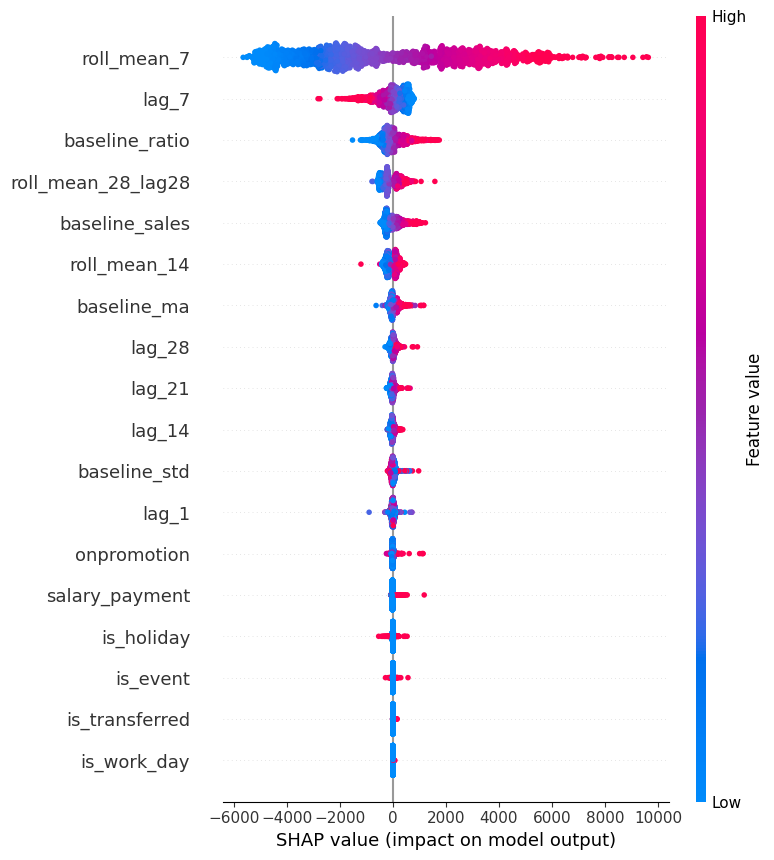

In [27]:
import shap

explainer = shap.TreeExplainer(final_model)
X_sample = df_trainval[FEATURES].sample(
    n=min(2000, len(df_trainval)),  # take up to 2000 rows max
    random_state=42
)

shap_values = explainer(X_sample)

shap.summary_plot(shap_values, X_sample)


## 8. Plot Forecasts - BASELINE, XGB


Plot total daily, weekly, and monthly forecasts using matplotlib for visual inspection.

In [28]:
def plot_forecast(df_forecast, date_col='date', value_col='pred_xgb', title='Forecast'):
    plt.figure(figsize=(12, 5))
    plt.plot(df_forecast[date_col], df_forecast[value_col], marker='o')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

# Plot total daily forecast
plot_forecast(daily_forecast_xgb.groupby('date')['pred_xgb'].sum().reset_index(), title='Total Daily Forecast (sum all stores/items)')

# Plot weekly forecast
plot_forecast(weekly_forecast_2weeks_xgb, date_col='week', title='Weekly Forecast (per store)')

# Plot monthly forecast
plot_forecast(monthly_forecast_2months_xgb, date_col='month', title='Monthly Forecast (per item)')

NameError: name 'daily_forecast_xgb' is not defined

## 8.2 Plot Daily Total Sales + Forecasts - BASELINE, XGB

In [ ]:
# Plot total sales: actuals (train/test), test predictions, and forecast

train_total = df_trainval.groupby('date')['unit_sales'].sum().reset_index()
test_total = df_test_final.groupby('date')[['unit_sales', 'pred_lgb']].sum().reset_index()
forecast_total = daily_forecast_xgb.groupby('date')['pred_lgb'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(train_total['date'], train_total['unit_sales'], label='Train Actual', color='blue')
plt.plot(test_total['date'], test_total['unit_sales'], label='Test Actual', color='green')
plt.plot(test_total['date'], test_total['pred_xgb'], label='Test Prediction (XGB)', color='orange')
plt.plot(forecast_total['date'], forecast_total['pred_xgb'], label='7-Day Forecast (XGB)', color='red', marker='o')

plt.title('Total Sales: Actuals, Predictions, and 7-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

## 8.3 Plot Daily Total Sales + Forecasts for an ITEM/STORE combination - BASELINE, XGB

In [ ]:
# Plot actuals and predictions for train, test, and forecast for a single store/item
from datetime import datetime
store_id = 44
item_id = 1971328

# Get data for this store/item
df_train = df_trainval[(df_trainval['store_nbr'] == store_id) & (df_trainval['item_nbr'] == item_id)].copy()
df_test = df_test_final[(df_test_final['store_nbr'] == store_id) & (df_test_final['item_nbr'] == item_id)].copy()
df_forecast_xgb = daily_forecast_xgb[(daily_forecast_xgb['store_nbr'] == store_id) & (daily_forecast_xgb['item_nbr'] == item_id)].copy()
df_train = df_train.reset_index().copy()
df_test = df_test.reset_index().copy()
df_forecast_xgb = df_forecast_xgb.reset_index().copy()

plt.figure(figsize=(14, 6))


plt.plot(df_train['date'], df_train['unit_sales'], label='Train Actual', color='blue')
plt.plot(df_test['date'], df_test['unit_sales'], label='Test Actual', color='green')
plt.plot(df_test['date'], df_test['pred_xgb'], label='Test Prediction (XGB)', color='orange')
plt.plot(df_forecast_xgb['date'], df_forecast_xgb['pred_xgb'], label='7-Day Forecast (XGB)', color='red', marker='o')

plt.title(f'Store {store_id}, Item {item_id}: Actuals, Predictions, and Forecast')
plt.xlabel('Date')
plt.xlim(left=datetime(2017, 3, 1), right=datetime(2017,11,1) )
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

## 9. Save Forecast Outputs

Save the daily, weekly, and monthly forecast DataFrames to CSV files for downstream use.

In [ ]:
daily_forecast_xgb.to_csv('../data/daily_forecast_xgb.csv', index=False)
weekly_forecast_2weeks_xgb.to_csv('../data/weekly_forecast_xgb.csv', index=False)
monthly_forecast_2months_xgb.to_csv('../data/monthly_forecast_xgb.csv', index=False)



In [ ]:
# Analyze feature correlations and importance
print("Feature correlations with target (unit_sales):")
correlations = df_model[WEEKLY_FEATURES + [TARGET]].corr()[TARGET].sort_values(ascending=False)
print(correlations.to_string())

print("\nFeature correlations with baseline_ratio:")
baseline_corr = df_model[WEEKLY_FEATURES].corrwith(df_model['baseline_ratio']).sort_values(ascending=False)
print(baseline_corr.to_string())

# Check data distribution before/after transformation
if 'baseline_ratio' in df_model.columns and 'log_baseline_ratio' in df_model.columns:
    print("\nBaseline ratio stats:")
    print(df_model['baseline_ratio'].describe())
    print("\nlog_baseline_ratio stats:")
    print(df_model['log_baseline_ratio'].describe())

    # Check if we have any extreme values that might be affecting the model
    print("\nExtreme values check:")
    print(f"Values > 10x baseline: {(df_model['baseline_ratio'] > 10).sum():,} records")
    print(f"Values < 0.1x baseline: {(df_model['baseline_ratio'] < 0.1).sum():,} records")

# Print correlation matrix heatmap data
print("\nFeature correlation matrix:")
correlation_matrix = df_model[WEEKLY_FEATURES].corr().round(3)
print(correlation_matrix.to_string())